# Seq2Seq으로 한국어 번역기 만들기

- seq2seq + Bahdanau Attention 구조 이용한 한국어 -> 영어 번역기 만들기
- 한국어 Mecab 형태소 분석
- 영어 공백 기준 토큰
- GRU Encoder-Decoder
- Greedy Decoding

- Mecab 설치

In [ ]:

!pip install konlpy
!git clone https://github.com/SOMJANG/Mecab-ko-for-Google-Colab.git
%cd Mecab-ko-for-Google-Colab
!bash install_mecab-ko_on_colab_light_220429.sh
%cd ..

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.0/438.0 kB 42.2 MB/s eta 0:00:00
Cloning into 'Mecab-ko-for-Google-Colab'...
remote: Enumerating objects: 138, done.
remote: Counting objects: 100% (47/47), done.
remote: Compressing objects: 100% (38/38), done.
remote: Total 138 (delta 26), reused 22 (delta 8), pack-reused 91 (from 1)
Receiving objects: 100% (138/138), 1.72 MiB | 32.52 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/content/Mecab-ko-for-Google-Colab
Installing konlpy.....
Done
Installing mecab-0.996-ko-0.9.2.tar.gz.....
from https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
--2026-05-05 10:13:37--  https://bitbucket.org/eunjeon/mecab-ko/downloads/mecab-0.996-ko-0.9.2.tar.gz
Resolving bitbucket.org (bitbucket.org)... 104.192.142.25, 104.192.142.24, 104.192.142.26, ...
Connecting to bitbucket.org (bitbucket.org)|104.192.142.25|:443... connected.
HTTP request sent, 

In [ ]:
# Mecab 정상 동작 확인
from konlpy.tag import Mecab

mecab = Mecab()

# 테스트 문장 (Step 5의 예문 중 하나)
test_sentence = "오바마는 대통령이다."

print("원문:", test_sentence)
print("형태소 분리:", mecab.morphs(test_sentence))
print("품사 태깅:", mecab.pos(test_sentence))

원문: 오바마는 대통령이다.
형태소 분리: ['오바마', '는', '대통령', '이', '다', '.']
품사 태깅: [('오바마', 'NNP'), ('는', 'JX'), ('대통령', 'NNG'), ('이', 'VCP'), ('다', 'EF'), ('.', 'SF')]


## Step 1. 데이터 준비
### 1. 데이터 다운로드 및 압축해제
- korean-english-park.train.tar.gz 를 다운로드받아 한영 병렬 데이터를 확보
- **출처**: [jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora)
- **파일**: `korean-english-park.train.tar.gz`
- **구성**: 압축 해제 시 두 개의 파일이 생성.
  - `korean-english-park.train.ko` — 한국어 문장 (한 줄에 하나)
  - `korean-english-park.train.en` — 영어 문장 (한 줄에 하나)
- **특징**: 두 파일은 **줄 단위로 1:1 대응**되는 병렬 말뭉치

- **저장 경로**: `./translator/datasets/`

In [ ]:
import os
import urllib.request
import tarfile

# 데이터 저장 디렉토리 생성
DATASET_DIR = "./translator/datasets"
os.makedirs(DATASET_DIR, exist_ok=True)

# 다운로드 URL (GitHub raw 링크)
url = "https://github.com/jungyeul/korean-parallel-corpora/raw/master/korean-english-news-v1/korean-english-park.train.tar.gz"
tar_path = os.path.join(DATASET_DIR, "korean-english-park.train.tar.gz")

# 다운로드 (이미 있으면 스킵)
if not os.path.exists(tar_path):
    print("데이터 다운로드 중...")
    urllib.request.urlretrieve(url, tar_path)
    print(f"다운로드 완료: {tar_path}")
else:
    print(f"이미 다운로드 완료: {tar_path}")

# 압축 해제
print("\n압축 해제 중...")
with tarfile.open(tar_path, "r:gz") as tar:
    tar.extractall(path=DATASET_DIR)
print("압축 해제 완료!")

# 디렉토리 내 파일 확인
print(f"\n[{DATASET_DIR}] 디렉토리 내용:")
for f in os.listdir(DATASET_DIR):
    full_path = os.path.join(DATASET_DIR, f)
    size = os.path.getsize(full_path) / 1024  # KB 단위
    print(f"  - {f} ({size:.1f} KB)")

데이터 다운로드 중...
다운로드 완료: ./translator/datasets/korean-english-park.train.tar.gz

압축 해제 중...
압축 해제 완료!

[./translator/datasets] 디렉토리 내용:
  - korean-english-park.train.ko (13409.1 KB)
  - korean-english-park.train.tar.gz (8514.5 KB)
  - korean-english-park.train.en (11701.4 KB)


/tmp/ipykernel_4127/3063595342.py:24: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=DATASET_DIR)


### 2. 데이터 로드 및 확인
압축 해제된 두 파일을 읽어 한국어/영어 문장 리스트로 만들고, 다음을 확인한다.

1. **데이터 개수**: 한국어와 영어 문장 수가 일치하는지 (병렬 말뭉치 무결성 검증)
2. **샘플 출력**: 실제 데이터 형태 확인
3. **인코딩**: UTF-8로 읽어 한글이 정상 표시되는지 확인

In [ ]:
# 한국어/영어 파일 경로
ko_path = os.path.join(DATASET_DIR, "korean-english-park.train.ko")
en_path = os.path.join(DATASET_DIR, "korean-english-park.train.en")

# 파일 읽기 (한 줄 = 한 문장)
with open(ko_path, "r", encoding="utf-8") as f:
    kor_lines = [line.strip() for line in f.readlines()]

with open(en_path, "r", encoding="utf-8") as f:
    eng_lines = [line.strip() for line in f.readlines()]

# 데이터 개수 확인
print(f"한국어 문장 수: {len(kor_lines):,}")
print(f"영어 문장 수: {len(eng_lines):,}")
assert len(kor_lines) == len(eng_lines), "병렬 데이터 개수 불일치!"
print(">>> 병렬 데이터 무결성 OK\n")

# 샘플 출력 (처음 3개, 마지막 2개)
print("=" * 60)
print("샘플 데이터 (처음 3개)")
print("=" * 60)
for i in range(3):
    print(f"[{i}] KO: {kor_lines[i]}")
    print(f"    EN: {eng_lines[i]}")
    print()

print("=" * 60)
print("샘플 데이터 (마지막 2개)")
print("=" * 60)
for i in range(-2, 0):
    print(f"[{i}] KO: {kor_lines[i]}")
    print(f"    EN: {eng_lines[i]}")
    print()

한국어 문장 수: 94,123
영어 문장 수: 94,123
>>> 병렬 데이터 무결성 OK

샘플 데이터 (처음 3개)
[0] KO: 개인용 컴퓨터 사용의 상당 부분은 "이것보다 뛰어날 수 있느냐?"
    EN: Much of personal computing is about "can you top this?"

[1] KO: 모든 광마우스와 마찬가지 로 이 광마우스도 책상 위에 놓는 마우스 패드를 필요로 하지 않는다.
    EN: so a mention a few weeks ago about a rechargeable wireless optical mouse brought in another rechargeable, wireless mouse.

[2] KO: 그러나 이것은 또한 책상도 필요로 하지 않는다.
    EN: Like all optical mice, But it also doesn't need a desk.

샘플 데이터 (마지막 2개)
[-2] KO: 김회장과 그의 아들은 보복폭행 혐의를 강력히 부인하고 있다.
    EN: Kim and his son both deny the allegations.

[-1] KO: 경찰은 김회장의 집무실에서 추가 증거를 찾은 이후 가능한 한 오늘 김회장과 아들을 구속수사 할 방침이다.
    EN: Police are planning to seek arrest warrants for Kim and his son as early as today, after searching the premises and securing additional material evidence.



## Step 2. 데이터 정제
1. **중복 제거**: `set` 자료형을 활용해 중복 쌍 제거 (병렬 정렬 유지)
2. **전처리 함수 재정의**: 영문 전용 정규식을 한글에도 적용 가능하도록 확장
3. **토큰화**: 영문은 `<start>`/`<end>` 추가 후 `split()`, 한글은 Mecab 형태소 분석
4. **길이 필터링**: 토큰 길이 ≤ 40인 데이터만 선별

### 2-1. 중복 제거

`set`은 중복을 허용하지 않는 자료형. 한국어/영어 문장을 **튜플 `(ko, en)`** 으로 묶어 set에 넣으면 병렬 쌍 단위로 중복이 제거됨.

> **주의**: ko 따로, en 따로 set에 넣으면 정렬이 깨지므로 반드시 쌍으로 묶어서 처리

In [ ]:
# 한국어/영어 문장을 튜플 쌍으로 묶어서 중복 제거
# (ko, en) 튜플을 set에 넣으면 같은 쌍이 여러 번 있어도 1개만 남음
print(f"중복 제거 전: {len(kor_lines):,} 쌍")

cleaned_corpus = set(zip(kor_lines, eng_lines))

print(f"중복 제거 후: {len(cleaned_corpus):,} 쌍")
print(f"제거된 중복: {len(kor_lines) - len(cleaned_corpus):,} 쌍")

# set은 순서가 없으므로 list로 변환 (이후 처리 편의)
cleaned_corpus = list(cleaned_corpus)

# 샘플 확인
print("\n중복 제거 후 샘플:")
for i in range(3):
    ko, en = cleaned_corpus[i]
    print(f"  KO: {ko}")
    print(f"  EN: {en}\n")

중복 제거 전: 94,123 쌍
중복 제거 후: 78,941 쌍
제거된 중복: 15,182 쌍

중복 제거 후 샘플:
  KO: 인수는 집에 컴퓨터가 1대 더 있어야 한다고 생각하지만 아버지께서 기말고사 시험성적이 좋으면 사주겠다고 약속한 최신 LG 휴대폰을 사기 전까지 컴퓨터는 살 수 없다.
  EN: Time to purchase a second PC, Insoo thinks but not before he gets his hands on the slick new LG phone, which Insoo's father had promised to buy him if he excels on the upcoming finals.

  KO: “오바마가 패배할 수 있는 시나리오는 여전히 존재합니다.”
  EN: “There still are scenarios under which he could lose.”

  KO: 라고 Karlsson이 말했다. "국방성은 그러한 로보트를 여러 대 갖고 있으며, 그 로보트들은 미국과 유럽의 핵 발전소에서 사용되고 있지만, 시장은 아직도 한계를 벗어나지 못하고 있습니다."
  EN: “The Pentagon have several, and they are used in nuclear plants in the United States and Europe, but the market is still rather marginal."



### 2-2. 전처리 함수 재정의 (한글 지원)

`node2.ipynb`의 원본 함수는 정규식 `[^a-zA-Z?.!,]+`로 영문/문장부호 외 모든 문자를 제거하므로, **한글이 모두 사라지는 문제**가 있음.

**수정 사항:**
- 한글 유니코드 범위 `가-힣`을 허용 문자에 추가
- 한자(가끔 등장), 숫자도 추가로 허용 (뉴스 데이터 특성 반영)
- 영문은 소문자화하되, 한글에는 적용하지 않음 (한글은 대소문자 구분 없음)

**처리 내용:**
1. 앞뒤 공백 제거 + (영문이면) 소문자화
2. 문장부호 `?.!,` 앞뒤에 공백 추가 → 토큰화 시 단어와 분리되도록
3. 허용 문자 외 모두 공백으로 치환
4. 연속 공백을 하나로 압축

In [ ]:
import re

########################################################
# 한글/영문 모두 처리 가능한 전처리 함수
# Args:
#     sentence: 입력 문장
#     is_korean: True면 한글 모드 (소문자화 X, 한글 허용)
########################################################
def preprocess_sentence(sentence, is_korean=False):

    # 영문일 때만 소문자화 (한글은 대소문자 구분 없음)
    if not is_korean:
        sentence = sentence.lower()

    # 문장부호 앞뒤에 공백 추가 ("hello,world" → "hello , world")
    sentence = re.sub(r"([?.!,])", r" \1 ", sentence)

    # 연속 공백을 하나로 압축
    sentence = re.sub(r'\s+', " ", sentence)

    # 허용 문자 외 모두 공백으로 치환
    if is_korean:
        # 한글(가-힣), 영문, 숫자, 문장부호 허용
        sentence = re.sub(r"[^가-힣a-zA-Z0-9?.!,]+", " ", sentence)
    else:
        # 영문, 문장부호만 허용
        sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)

    sentence = sentence.strip()
    return sentence


# 동작 확인
print("[한글 전처리]")
print(preprocess_sentence("오바마는, 미국의 44대 대통령이다!!", is_korean=True))
print(preprocess_sentence("커피는 필요 없다.", is_korean=True))

print("\n[영문 전처리]")
print(preprocess_sentence("Obama is the 44th President of the USA!!", is_korean=False))
print(preprocess_sentence("I don't need coffee.", is_korean=False))

[한글 전처리]
오바마는 , 미국의 44대 대통령이다 ! !
커피는 필요 없다 .

[영문 전처리]
obama is the th president of the usa ! !
i don t need coffee .


### 2-3. 토큰화

**영문 (타겟):**
- 전처리 후 `split()`으로 공백 기준 분리
- 시작/종료 토큰 `<start>`, `<end>` 추가 → Decoder 학습 시 시작 신호와 종료 신호로 사용

**한글 (소스):**
- KoNLPy의 `Mecab.morphs()`로 형태소 단위 분리
- 조사/어미가 분리되어 단어 의미 학습에 유리

**예시:**
- 한글: "오바마는 대통령이다." → ['오바마', '는', '대통령', '이', '다', '.']
- 영문: "obama is a president." → ['<start>', 'obama', 'is', 'a', 'president', '.', '<end>']

In [ ]:
from konlpy.tag import Mecab
from tqdm import tqdm

mecab = Mecab()

# 한글 문장을 Mecab 형태소로 토큰화
def tokenize_kor(sentence):
    sentence = preprocess_sentence(sentence, is_korean=True)
    return mecab.morphs(sentence)

# 영문 문장을 split() 토큰화 + <start>/<end> 추가
def tokenize_eng(sentence):
    sentence = preprocess_sentence(sentence, is_korean=False)
    tokens = sentence.split()
    return ["<start>"] + tokens + ["<end>"]


# 전체 데이터 토큰화 (시간 소요됨, tqdm으로 진행률 표시)
print("토큰화 진행 중...")
kor_tokens = []
eng_tokens = []

for ko, en in tqdm(cleaned_corpus, desc="Tokenizing"):
    kor_tokens.append(tokenize_kor(ko))
    eng_tokens.append(tokenize_eng(en))

print(f"\n토큰화 완료: {len(kor_tokens):,} 쌍")

# 샘플 확인
print("\n토큰화 샘플:")
for i in range(3):
    print(f"  KO: {kor_tokens[i]}")
    print(f"  EN: {eng_tokens[i]}\n")

토큰화 진행 중...


Tokenizing: 100%|██████████| 78941/78941 [00:13<00:00, 5964.24it/s]


토큰화 완료: 78,941 쌍

토큰화 샘플:
  KO: ['인수', '는', '집', '에', '컴퓨터', '가', '1', '대', '더', '있', '어야', '한다고', '생각', '하', '지만', '아버지', '께서', '기말고사', '시험', '성적', '이', '좋', '으면', '사', '주', '겠', '다고', '약속', '한', '최신', 'LG', '휴대폰', '을', '사', '기', '전', '까지', '컴퓨터', '는', '살', '수', '없', '다', '.']
  EN: ['<start>', 'time', 'to', 'purchase', 'a', 'second', 'pc', ',', 'insoo', 'thinks', 'but', 'not', 'before', 'he', 'gets', 'his', 'hands', 'on', 'the', 'slick', 'new', 'lg', 'phone', ',', 'which', 'insoo', 's', 'father', 'had', 'promised', 'to', 'buy', 'him', 'if', 'he', 'excels', 'on', 'the', 'upcoming', 'finals', '.', '<end>']

  KO: ['오바마', '가', '패배', '할', '수', '있', '는', '시나리오', '는', '여전히', '존재', '합니다', '.']
  EN: ['<start>', 'there', 'still', 'are', 'scenarios', 'under', 'which', 'he', 'could', 'lose', '.', '<end>']

  KO: ['라고', 'Karlsson', '이', '말', '했', '다', '.', '국방성', '은', '그러', '한', '로보트', '를', '여러', '대', '갖', '고', '있', '으며', ',', '그', '로보트', '들', '은', '미국', '과', '유럽', '의', '핵', '발전소', '에서', '사용',

### 2-4. 길이 필터링

전체 데이터 학습은 시간이 너무 오래 걸리므로, **토큰 길이 ≤ 40**인 데이터만 선별.

- 한국어와 영어 **둘 다** 40 이하여야 통과
- 이렇게 만든 결과를 `kor_corpus`, `eng_corpus`로 저장
- 추가로 토큰 길이 분포를 시각화하여 데이터 특성 파악

필터링 전: 78,941 쌍
필터링 후: 61,510 쌍
제거된 데이터: 17,431 쌍


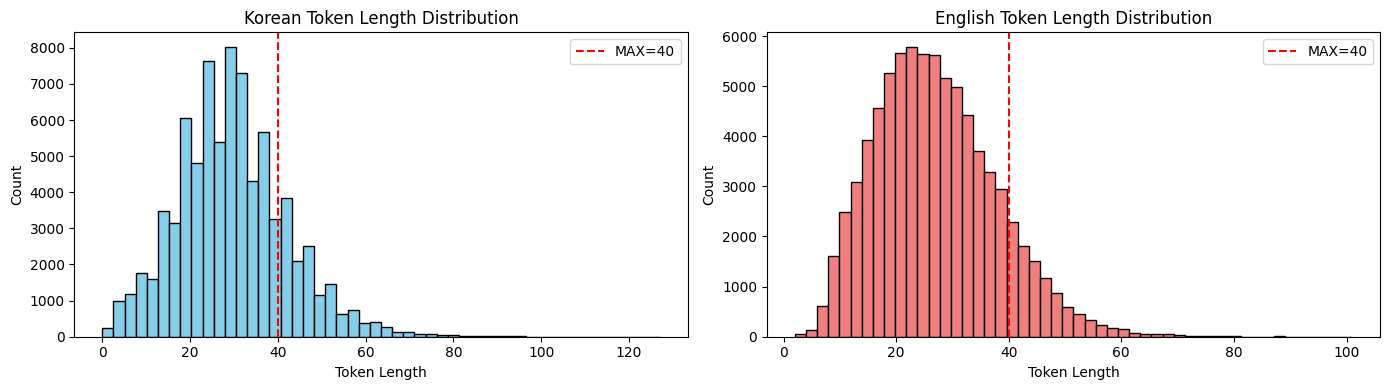


[필터링 후 통계]
  KO 토큰 길이 - 평균: 25.0, 최대: 40, 최소: 0
  EN 토큰 길이 - 평균: 23.1, 최대: 40, 최소: 2


In [ ]:
import matplotlib.pyplot as plt

MAX_TOKEN_LEN = 40

# 길이 필터링: 한/영 모두 40 이하인 쌍만 남김
kor_corpus = []
eng_corpus = []

for ko_t, en_t in zip(kor_tokens, eng_tokens):
    if len(ko_t) <= MAX_TOKEN_LEN and len(en_t) <= MAX_TOKEN_LEN:
        kor_corpus.append(ko_t)
        eng_corpus.append(en_t)

print(f"필터링 전: {len(kor_tokens):,} 쌍")
print(f"필터링 후: {len(kor_corpus):,} 쌍")
print(f"제거된 데이터: {len(kor_tokens) - len(kor_corpus):,} 쌍")

# 토큰 길이 분포 시각화 (필터링 전 기준)
kor_lens = [len(t) for t in kor_tokens]
eng_lens = [len(t) for t in eng_tokens]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(kor_lens, bins=50, color='skyblue', edgecolor='black')
axes[0].axvline(x=MAX_TOKEN_LEN, color='red', linestyle='--', label=f'MAX={MAX_TOKEN_LEN}')
axes[0].set_title('Korean Token Length Distribution')
axes[0].set_xlabel('Token Length')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(eng_lens, bins=50, color='lightcoral', edgecolor='black')
axes[1].axvline(x=MAX_TOKEN_LEN, color='red', linestyle='--', label=f'MAX={MAX_TOKEN_LEN}')
axes[1].set_title('English Token Length Distribution')
axes[1].set_xlabel('Token Length')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

# 통계 요약
import numpy as np
print(f"\n[필터링 후 통계]")
filt_kor_lens = [len(t) for t in kor_corpus]
filt_eng_lens = [len(t) for t in eng_corpus]
print(f"  KO 토큰 길이 - 평균: {np.mean(filt_kor_lens):.1f}, 최대: {max(filt_kor_lens)}, 최소: {min(filt_kor_lens)}")
print(f"  EN 토큰 길이 - 평균: {np.mean(filt_eng_lens):.1f}, 최대: {max(filt_eng_lens)}, 최소: {min(filt_eng_lens)}")

**확인결과**
- 한국어가 평균/최대 모두 더 김.
- Mecab이 형태소 단위로 잘게 쪼개기 때문 ("대통령이다" → "대통령", "이", "다")
- 영문 split()은 단어 단위라 토큰 수가 적음
- 같은 의미를 한국어가 더 많은 토큰으로 표현하는 경향

**비정상 데이터**
- KO 최소 길이: 0

  - 전처리 후 완전히 비어버린 한국어 문장이 존재
  - 원인: 한자/특수문자만 있던 문장이 정규식으로 모두 제거됨
  - 또는 원본이 빈 줄이거나 공백뿐인 경우

- EN 최소 길이: 2

  - <start> + <end> 만 있고 본문 토큰이 0개 => 마찬가지로 빈 문장


**비정상데이터 최소길이 필터추가 보완**  

In [ ]:
# 수정: 최소 길이 조건 추가 (빈 문장 / 너무 짧은 문장 제거)
MAX_TOKEN_LEN = 40
MIN_TOKEN_LEN = 3   # KO 최소 3 토큰, EN은 <start>+1단어+<end> = 최소 3 토큰

kor_corpus = []
eng_corpus = []

for ko_t, en_t in zip(kor_tokens, eng_tokens):
    # 한/영 모두 최소 길이 이상 + 최대 길이 이하
    if (MIN_TOKEN_LEN <= len(ko_t) <= MAX_TOKEN_LEN and
        MIN_TOKEN_LEN <= len(en_t) <= MAX_TOKEN_LEN):
        kor_corpus.append(ko_t)
        eng_corpus.append(en_t)

print(f"필터링 후: {len(kor_corpus):,} 쌍")

# 통계 재확인
import numpy as np
filt_kor_lens = [len(t) for t in kor_corpus]
filt_eng_lens = [len(t) for t in eng_corpus]
print(f"\n[수정된 필터링 후 통계]")
print(f"  KO 토큰 길이 - 평균: {np.mean(filt_kor_lens):.1f}, 최대: {max(filt_kor_lens)}, 최소: {min(filt_kor_lens)}")
print(f"  EN 토큰 길이 - 평균: {np.mean(filt_eng_lens):.1f}, 최대: {max(filt_eng_lens)}, 최소: {min(filt_eng_lens)}")

필터링 후: 61,258 쌍

[수정된 필터링 후 통계]
  KO 토큰 길이 - 평균: 25.1, 최대: 40, 최소: 3
  EN 토큰 길이 - 평균: 23.1, 최대: 40, 최소: 3


## Step 3. 데이터 토큰화(텐서변환)

지금까지 만든 `kor_corpus`, `eng_corpus`는 **문자열 토큰 리스트**.
모델 입력을 위해 **정수 인덱스 텐서**로 변환.

**처리 내용:**
1. `tokenize()` 함수 정의 (TF Keras `Tokenizer` 활용)
2. vocab 크기 결정을 위한 unique 토큰 수 분석
3. `tokenize()` 적용 → 정수 텐서 + tokenizer 객체 획득
4. 변환 결과 검증 (역변환 테스트, shape 확인)

**주의:**
- 모델은 PyTorch이지만 토크나이저는 TF Keras를 사용.
- 단어 수는 **최소 10,000 이상**, 실험적으로 결정.
- 훈련/검증 분할은 하지 않음. (데이터 양이 충분하지 않음)


### 3-1. tokenize() 함수 정의

tf.keras.preprocessing.text.Tokenizer를 사용해 토큰 리스트를 정수 시퀀스로 변환.

- **`num_words`**: vocab 크기 제한 (빈도 상위 N개 단어만 유지)
- **`filters=''`**: 이미 전처리/토큰화 완료했으므로 추가 필터 OFF
- **`oov_token="<unk>"`**: vocab에 없는 단어는 `<unk>`로 처리
- **`pad_sequences`**: 짧은 문장에 0을 채워 길이 통일 (`padding='post'` = 뒤쪽에 패딩)

In [ ]:
import tensorflow as tf

###############################################
# 토큰 리스트를 정수 텐서로 변환
# Args:
#     corpus: 토큰 리스트의 리스트
#             예: [['<start>', 'hello', '.', '<end>'], ...]
#     num_words: vocab 크기 제한 (None=전체)

# Returns:
#     tensor: 패딩된 정수 시퀀스 (numpy array, shape=(N, max_len))
#     tokenizer: 학습된 Tokenizer 객체
###############################################
def tokenize(corpus, num_words=None):

    # 토큰 리스트를 공백으로 join (Tokenizer는 문자열 입력)
    # mecab/split 토큰들은 내부에 공백이 없으므로 안전하게 join 가능
    text_corpus = [' '.join(tokens) for tokens in corpus]

    tokenizer = tf.keras.preprocessing.text.Tokenizer(
        num_words=num_words,
        filters='',           # 추가 필터링 비활성화
        oov_token="<unk>"     # 미등록 단어 처리
    )
    tokenizer.fit_on_texts(text_corpus)  # 단어사전 등록

    # 문장을 정수 인덱스 시퀀스로 변환
    tensor = tokenizer.texts_to_sequences(text_corpus)

    # 길이 통일을 위해 패딩 추가 (뒤쪽에 0)
    tensor = tf.keras.preprocessing.sequence.pad_sequences(tensor, padding='post')

    return tensor, tokenizer

print("tokenize() 함수 정의 완료")

tokenize() 함수 정의 완료


### 3-2. Vocab 크기 결정 분석

적절한 `num_words` 값을 정하기 위해 **전체 unique 토큰 수**를 확인.

- vocab이 너무 작으면 → `<unk>` 비율 ↑, 번역 품질 ↓
- vocab이 너무 크면 → 모델 파라미터 ↑, 학습 시간 ↑, 희귀 단어 학습 어려움
- 일반적으로 **상위 빈도 80~95% 커버하는 크기**가 적절

In [ ]:
from collections import Counter

# 전체 토큰 빈도 집계
kor_token_counter = Counter([t for sent in kor_corpus for t in sent])
eng_token_counter = Counter([t for sent in eng_corpus for t in sent])

print(f"한국어 unique 토큰 수: {len(kor_token_counter):,}")
print(f"영어 unique 토큰 수: {len(eng_token_counter):,}")

# 누적 커버리지 계산 (vocab_size별로 전체 토큰의 몇%를 커버하는지)
def cumulative_coverage(counter, sizes):
    total = sum(counter.values())
    sorted_counts = sorted(counter.values(), reverse=True)
    print(f"\n  vocab_size | 커버리지")
    print(f"  -----------+----------")
    for size in sizes:
        covered = sum(sorted_counts[:size])
        print(f"  {size:>10,} | {covered/total*100:.2f}%")

print("\n[한국어 vocab 크기별 커버리지]")
cumulative_coverage(kor_token_counter, [5000, 10000, 15000, 20000, 30000])

print("\n[영어 vocab 크기별 커버리지]")
cumulative_coverage(eng_token_counter, [5000, 10000, 15000, 20000, 30000])

한국어 unique 토큰 수: 45,892
영어 unique 토큰 수: 37,932

[한국어 vocab 크기별 커버리지]

  vocab_size | 커버리지
  -----------+----------
       5,000 | 90.47%
      10,000 | 94.82%
      15,000 | 96.71%
      20,000 | 97.80%
      30,000 | 98.97%

[영어 vocab 크기별 커버리지]

  vocab_size | 커버리지
  -----------+----------
       5,000 | 91.31%
      10,000 | 95.65%
      15,000 | 97.46%
      20,000 | 98.44%
      30,000 | 99.44%


### 3-3. 토큰화 실행

위 분석 결과를 참고해 `vocab_size`를 결정.

**분석결과**
| vocab_size | 한국어 | 영어 |
|---|---|---|
| 10,000 | 94.82% | 95.65% |
| **15,000** | **96.71%** | **97.46%** |
| 20,000 | 97.80% | 98.44% |
| 30,000 | 98.97% | 99.44% |

**선택 근거:**

1. **충분한 커버리지**: 한/영 모두 약 97% 커버 — `<unk>` 비율 3% 수준으로 번역 품질에 큰 영향 없음

2. **한계효용 급감**: 15K → 20K로 vocab을 33% 늘려도 커버리지는 1%만 증가. 희귀 단어들이라 어차피 학습이 어려움

3. **모델 크기 효율**: Embedding과 출력층이 vocab 크기에 비례 — 15K 유지 시 학습 속도와 메모리 효율 확보

4. **데이터 규모와 균형**: 약 61K 쌍의 데이터로 15K vocab을 학습하기에 적절 (단어당 평균 등장 빈도 충분)

  → **`KOR_VOCAB_SIZE = ENG_VOCAB_SIZE = 15,000`**


**권장 값** (실행 결과 보고 조정):
- **한국어**: 15,000 (Mecab은 형태소 단위라 unique 토큰 많음)
- **영어**: 15,000 (split 단위라 상대적으로 적음)

> 두 언어 vocab 크기를 다르게 설정해도 모델 학습에는 문제 없음.
> Encoder/Decoder가 각각 독립된 임베딩 레이어를 갖기 때문.

In [ ]:
# vocab 크기 설정 (위 분석 결과 보고 조정)
KOR_VOCAB_SIZE = 15000
ENG_VOCAB_SIZE = 15000

# 토큰화 실행
print("한국어 토큰화 중...")
kor_tensor, kor_tokenizer = tokenize(kor_corpus, num_words=KOR_VOCAB_SIZE)

print("영어 토큰화 중...")
eng_tensor, eng_tokenizer = tokenize(eng_corpus, num_words=ENG_VOCAB_SIZE)

# 결과 확인
print(f"\n[텐서 shape]")
print(f"  KOR tensor: {kor_tensor.shape}  (문장 수, 최대 길이)")
print(f"  ENG tensor: {eng_tensor.shape}")

print(f"\n[실제 vocab 크기]")
# Tokenizer의 word_index에는 모든 단어가 들어있지만,
# num_words 제한으로 인해 변환 시 사용되는 vocab은 num_words+1개 (0=padding)
print(f"  KOR Tokenizer 전체 vocab: {len(kor_tokenizer.word_index):,}")
print(f"  KOR 실제 사용 vocab (제한): {KOR_VOCAB_SIZE:,}")
print(f"  ENG Tokenizer 전체 vocab: {len(eng_tokenizer.word_index):,}")
print(f"  ENG 실제 사용 vocab (제한): {ENG_VOCAB_SIZE:,}")

한국어 토큰화 중...
영어 토큰화 중...

[텐서 shape]
  KOR tensor: (61258, 40)  (문장 수, 최대 길이)
  ENG tensor: (61258, 40)

[실제 vocab 크기]
  KOR Tokenizer 전체 vocab: 44,859
  KOR 실제 사용 vocab (제한): 15,000
  ENG Tokenizer 전체 vocab: 37,933
  ENG 실제 사용 vocab (제한): 15,000


### 3-4. 변환 검증

토큰화가 정상적으로 되었는지 **역변환 테스트**로 확인.

- 정수 인덱스 → 단어로 복원해 원문과 비교
- 특수 토큰 (`<start>`, `<end>`, `<unk>`) 인덱스 확인
- 패딩(0)이 올바르게 들어갔는지 확인

In [ ]:
# 특수 토큰 인덱스 확인
print("[영어 특수 토큰 인덱스]")
print(f"  <start>: {eng_tokenizer.word_index.get('<start>')}")
print(f"  <end>: {eng_tokenizer.word_index.get('<end>')}")
print(f"  <unk>: {eng_tokenizer.word_index.get('<unk>')}")

print("\n[한국어 특수 토큰 인덱스]")
print(f"  <unk>: {kor_tokenizer.word_index.get('<unk>')}")

# 샘플 역변환 테스트 (인덱스 → 단어)
print("\n[샘플 역변환 테스트]")
for i in [0, 100, 1000]:
    print(f"\n--- Sample {i} ---")

    # 한국어 원본 토큰
    print(f"  KOR 원본:  {' '.join(kor_corpus[i])}")
    # 정수 시퀀스
    print(f"  KOR 텐서:  {kor_tensor[i][:15]}...")
    # 역변환 (0 패딩 제외)
    kor_restored = kor_tokenizer.sequences_to_texts([kor_tensor[i]])[0]
    print(f"  KOR 복원:  {kor_restored}")

    print(f"  ENG 원본:  {' '.join(eng_corpus[i])}")
    print(f"  ENG 텐서:  {eng_tensor[i][:15]}...")
    eng_restored = eng_tokenizer.sequences_to_texts([eng_tensor[i]])[0]
    print(f"  ENG 복원:  {eng_restored}")

[영어 특수 토큰 인덱스]
  <start>: 4
  <end>: 5
  <unk>: 1

[한국어 특수 토큰 인덱스]
  <unk>: 1

[샘플 역변환 테스트]

--- Sample 0 ---
  KOR 원본:  오바마 가 패배 할 수 있 는 시나리오 는 여전히 존재 합니다 .
  KOR 텐서:  [ 116   14 1463   37   41   15    5 4058    5 1001 1588  350    2    0
    0]...
  KOR 복원:  오바마 가 패배 할 수 있 는 시나리오 는 여전히 존재 합니다 . <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>
  ENG 원본:  <start> there still are scenarios under which he could lose . <end>
  ENG 텐서:  [    4    72   159    31 10632   150    56    21    94  2441     3     5
     0     0     0]...
  ENG 복원:  <start> there still are scenarios under which he could lose . <end> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk> <unk>

--- Sample 100 ---
  KOR 원본:  탈레반 측 과 아프간 협상 자 들 이 30 일 현지 시간 협상 마감 시한 이 지난 이후 한국인 인질 22 명 에 대한 석방 협상 을 재개

## Step 4. 모델 설계
- 한국어를 영어로 잘 번역해 줄 Attention 기반 Seq2seq 모델을 설계.
GRU 기반 Encoder-Decoder 구조를 한영 번역에 맞게 사용하되, **Dropout을 추가**하여 과적합을 완화.

**전체 구조:**
```
[한글 문장] → Encoder (GRU) → encoder_outputs (모든 시점 hidden)
                                       ↓
                               Bahdanau Attention
                                       ↓
[<start>] → Decoder (GRU) ──→ context vector ──→ FC → [영어 단어 예측]
                ↑                                       ↓
                └── 다음 시점 입력으로 ←───────────────┘
```

**핵심:**
1. **Encoder**: 한글 입력을 받아 모든 시점의 hidden state 출력
2. **BahdanauAttention**: Decoder의 현재 hidden과 Encoder 출력 사이의 attention weight 계산
3. **Decoder**: 이전 단어 + attention context로 다음 단어 예측
4. **Seq2SeqAttention**: 위 컴포넌트를 통합한 학습/추론 모드 지원 모델

**하이퍼파라미터** (실험적 결정):
- embedding_dim: 256
- hidden_dim: 512
- dropout: 0.3 (과적합 방지)

### 4-1. Bahdanau Attention

Decoder의 현재 hidden state가 **Encoder의 어느 시점 정보에 주목할지** 가중치를 학습.

**계산 흐름:**
```
energy = tanh(W1 · encoder_outputs + W2 · decoder_hidden)
score  = v · energy
attention = softmax(score)   ← 입력 시점들에 대한 확률 분포
```

- W1, W2, v: 학습 가능한 선형 변환
- 출력 attention: shape (batch_size, src_len) — 각 입력 토큰에 대한 가중치

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        # 학습 가능한 3개 선형 변환
        self.W1 = nn.Linear(hidden_dim, hidden_dim)  # encoder_outputs용
        self.W2 = nn.Linear(hidden_dim, hidden_dim)  # decoder_hidden용
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_dim) — Decoder의 현재 hidden
        # encoder_outputs: (src_len, batch_size, hidden_dim)

        src_len = encoder_outputs.shape[0]

        # hidden을 src_len만큼 복제하여 각 시점과 비교 가능하게 만듦
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)         # (batch, src_len, hidden)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)         # (batch, src_len, hidden)

        # energy 계산: 두 정보를 결합
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))  # (batch, src_len, hidden)

        # score를 1차원으로 압축
        attention = self.v(energy).squeeze(2)  # (batch, src_len)

        # softmax로 확률 분포화
        return F.softmax(attention, dim=1)

print("BahdanauAttention 정의 완료")

BahdanauAttention 정의 완료


### 4-2. Encoder

한글 입력 시퀀스를 받아 **각 시점의 hidden state**를 모두 출력.

**구성:**
- Embedding: 토큰 인덱스를 dense vector로 변환
- GRU: 시퀀스를 순차적으로 처리하며 hidden state 누적
- Dropout: Embedding 출력에 적용 (과적합 방지)

**출력:**
- outputs: 모든 시점 hidden — Attention의 입력으로 사용
- hidden: 마지막 시점 hidden — Decoder의 초기 hidden으로 사용

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=0)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        # src: (src_len, batch_size)
        embedded = self.dropout(self.embedding(src))     # (src_len, batch, emb_dim)
        outputs, hidden = self.rnn(embedded)              # outputs: (src_len, batch, hidden)
        return outputs, hidden                            # hidden: (1, batch, hidden)

print("Encoder 정의 완료")

Encoder 정의 완료


### 4-3. Decoder

한 번에 **한 시점씩** 영어 단어를 생성.

**처리 흐름:**
1. 이전 시점 단어를 임베딩
2. Attention으로 Encoder 출력 중 어디에 주목할지 결정
3. 가중합으로 context vector 계산
4. GRU로 hidden state 업데이트
5. hidden + context를 결합해 다음 단어 예측

**핵심 차이점 (vs 일반 Decoder):**
- 출력층 입력이 hidden + context (concat) → 단순 hidden보다 풍부한 정보

In [ ]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, attention, dropout=0.3):
        super().__init__()
        self.output_dim = output_dim
        self.attention = attention
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=0)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        # 출력층: hidden + context를 결합한 입력 → vocab 크기로 변환
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    # input: (batch_size,) — 이전 시점 단어
    # hidden: (1, batch_size, hidden_dim)
    # encoder_outputs: (src_len, batch_size, hidden_dim)
    def forward(self, input, hidden, encoder_outputs):

        input = input.unsqueeze(0)                          # (1, batch_size)
        embedded = self.dropout(self.embedding(input))      # (1, batch, emb_dim)

        # Attention 가중치 계산
        a = self.attention(hidden[-1], encoder_outputs)     # (batch, src_len)

        # Context vector = attention 가중합
        a = a.unsqueeze(1)                                  # (batch, 1, src_len)
        encoder_outputs_perm = encoder_outputs.permute(1, 0, 2)   # (batch, src_len, hidden)
        context = torch.bmm(a, encoder_outputs_perm)        # (batch, 1, hidden)
        context = context.permute(1, 0, 2)                  # (1, batch, hidden)

        # GRU로 hidden 업데이트
        output, hidden = self.rnn(embedded, hidden)         # output: (1, batch, hidden)

        # hidden + context 결합 → 단어 예측
        output = output.squeeze(0)                          # (batch, hidden)
        context = context.squeeze(0)                        # (batch, hidden)
        prediction = self.fc_out(torch.cat((output, context), dim=1))  # (batch, vocab)

        return prediction, hidden, a.squeeze(1)             # attention 반환 (시각화용)

print("Decoder 정의 완료")

Decoder 정의 완료


### 4-4. Seq2SeqAttention (통합 모델)

Encoder와 Decoder를 통합하고, **학습/추론 모드를 모두 지원**.

**학습 모드 (trg 정답 입력 있음):**
- Teacher Forcing — 정답 단어를 Decoder 입력으로 사용
- 학습 안정성 ↑, 수렴 속도 ↑

**추론 모드 (trg=None):**
- `<start>` 토큰부터 시작
- 각 시점 예측을 다음 시점 입력으로 (Greedy Decoding)
- 모든 배치가 `<end>` 도달하면 조기 종료

In [ ]:
class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg=None, max_len=40, bos_id=1, eos_id=2):
        # src: (src_len, batch_size)
        # trg: (trg_len, batch_size) or None (추론 시)

        batch_size = src.shape[1]
        outputs = []
        attentions = []

        # Encoder 실행
        encoder_outputs, hidden = self.encoder(src)

        if trg is not None:
            # 학습 모드: Teacher Forcing
            for t in range(trg.shape[0]):
                input = trg[t]
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
        else:
            # 추론 모드: Greedy Decoding
            input = torch.full((batch_size,), bos_id, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)

            for t in range(max_len):
                output, hidden, attention = self.decoder(input, hidden, encoder_outputs)
                outputs.append(output.unsqueeze(0))
                attentions.append(attention.unsqueeze(0))
                top1 = output.argmax(1)
                input = top1

                # 조기 종료
                finished |= (top1 == eos_id)
                if finished.all():
                    break

        outputs = torch.cat(outputs, dim=0)        # (trg_len, batch, output_dim)
        attentions = torch.cat(attentions, dim=0)  # (trg_len, batch, src_len)
        return outputs, attentions

print("Seq2SeqAttention 정의 완료")

Seq2SeqAttention 정의 완료


### 4-5. 모델 인스턴스 생성

정의한 컴포넌트로 실제 모델을 만들고 GPU로 이동.

**하이퍼파라미터:**
- EMB_DIM = 256
- HID_DIM = 512
- DROPOUT = 0.3

모델 파라미터 수도 함께 출력하여 메모리 사용량을 가늠함.

In [ ]:
# 디바이스 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

# 하이퍼파라미터
INPUT_DIM = KOR_VOCAB_SIZE + 1   # padding(0) 포함
OUTPUT_DIM = ENG_VOCAB_SIZE + 1
EMB_DIM = 256
HID_DIM = 512
DROPOUT = 0.3

# 모델 구성
attention = BahdanauAttention(HID_DIM)
encoder = Encoder(INPUT_DIM, EMB_DIM, HID_DIM, DROPOUT)
decoder = Decoder(OUTPUT_DIM, EMB_DIM, HID_DIM, attention, DROPOUT)
model = Seq2SeqAttention(encoder, decoder, device).to(device)

# 모델 구조 출력
print("\n[모델 구조]")
print(model)

# 파라미터 수 계산
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = count_parameters(model)
print(f"\n총 학습 가능 파라미터: {total_params:,} ({total_params/1e6:.2f}M)")

사용 디바이스: cuda

[모델 구조]
Seq2SeqAttention(
  (encoder): Encoder(
    (embedding): Embedding(15001, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (decoder): Decoder(
    (attention): BahdanauAttention(
      (W1): Linear(in_features=512, out_features=512, bias=True)
      (W2): Linear(in_features=512, out_features=512, bias=True)
      (v): Linear(in_features=512, out_features=1, bias=False)
    )
    (embedding): Embedding(15001, 256, padding_idx=0)
    (rnn): GRU(256, 512)
    (fc_out): Linear(in_features=1024, out_features=15001, bias=True)
    (dropout): Dropout(p=0.3, inplace=False)
  )
)

총 학습 가능 파라미터: 25,947,801 (25.95M)


In [ ]:
# 학습/추론 시 사용할 특수 토큰 ID
BOS_ID = eng_tokenizer.word_index['<start>']
EOS_ID = eng_tokenizer.word_index['<end>']
PAD_ID = 0  # tf.keras Tokenizer의 padding은 항상 0

print(f"<start> ID: {BOS_ID}")
print(f"<end> ID: {EOS_ID}")
print(f"<pad> ID: {PAD_ID}")

<start> ID: 4
<end> ID: 5
<pad> ID: 0


## Step 5. 훈련하기 + 시각화
- 훈련엔 이전에 사용한 코드를 그대로 사용하되,  eval_step() 부분이 없음에 유의
- 매 에폭마다 예문 번역 결과 출력 (학습 진행 모니터링)
- Loss 곡선 시각화
- Attention Map을 시각화
- Early Stopping (loss 정체 시 자동 종료)
```
    #### 예문 ####
    K1) 오바마는 대통령이다.
    K2) 시민들은 도시 속에 산다.
    K3) 커피는 필요 없다.
    K4) 일곱 명의 사망자가 발생했다.
    
    #### 제출 ####
    E1) obama is the president . <end>
    E2) people are victims of the city . <end>
    E2) the price is not enough . <end>
    E2) seven people have died . <end>
```

**진행 순서:**
1. **5-1**: TranslationDataset + DataLoader 구성
2. **5-2**: 번역 함수 + Attention 시각화 함수 정의
3. **5-3**: Optimizer, Loss, train_step 정의
4. **5-4**: 학습 루프 실행
5. **5-5**: 최종 결과 + Attention Map 분석

### 5-1. TranslationDataset & DataLoader

**Teacher Forcing 학습용 데이터 구조:**

영어 텐서가 [<start>, w1, w2, ..., wn, <end>, 0, 0, ...] 형태이므로, 다음과 같이 분리.

- trg_input = 시퀀스의 **앞부분** (마지막 토큰 제외) — Decoder 입력용
  - [<start>, w1, w2, ..., wn, <end>, 0, ...]
- trg_label = 시퀀스의 **뒷부분** (첫 토큰 제외) — Decoder가 맞춰야 할 정답
  - [w1, w2, ..., wn, <end>, 0, 0, ...]

이렇게 하면 시점 t에서 `<start>` 보고 `w1` 예측하는 식으로 한 칸씩 밀린 정답을 학습.

In [ ]:
from torch.utils.data import Dataset, DataLoader

class TranslationDataset(Dataset):
    def __init__(self, src_tensor, trg_tensor):
        # numpy → torch.LongTensor로 변환 (정수 인덱스)
        self.src = torch.tensor(src_tensor, dtype=torch.long)
        self.trg = torch.tensor(trg_tensor, dtype=torch.long)

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        # Teacher Forcing 학습을 위한 입력/라벨 분리
        trg_input = self.trg[idx][:-1]   # 마지막 토큰 제외
        trg_label = self.trg[idx][1:]    # 첫 토큰 제외
        return self.src[idx], trg_input, trg_label


# 학습 데이터셋 생성 (검증 분할 없음 - 데이터 양 부족)
BATCH_SIZE = 64

train_dataset = TranslationDataset(kor_tensor, eng_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(f"학습 데이터 수: {len(train_dataset):,}")
print(f"배치 수: {len(train_loader):,} (배치 크기 {BATCH_SIZE})")

# 한 배치 shape 확인
for src, trg_input, trg_label in train_loader:
    print(f"\n[배치 shape]")
    print(f"  src:        {src.shape}        (batch, src_len)")
    print(f"  trg_input:  {trg_input.shape}  (batch, trg_len-1)")
    print(f"  trg_label:  {trg_label.shape}  (batch, trg_len-1)")
    break

학습 데이터 수: 61,258
배치 수: 958 (배치 크기 64)

[배치 shape]
  src:        torch.Size([64, 40])        (batch, src_len)
  trg_input:  torch.Size([64, 39])  (batch, trg_len-1)
  trg_label:  torch.Size([64, 39])  (batch, trg_len-1)


### 5-2. 번역 함수 + Attention 시각화

학습 중 매 에폭마다 예문 번역 품질을 확인하기 위해 미리 정의.

**translate(sentence, ...)**:
1. 한글 문장 → 전처리 → Mecab 토큰화 → 정수 인덱스
2. 모델로 추론 (Greedy Decoding)
3. 정수 → 영어 단어로 디코딩
4. `<end>` 만나면 중단

**plot_attention(...)**:
- (trg_len, src_len) 형태의 attention weight를 히트맵으로 시각화
- 영어 단어가 한국어 단어 어디에 주목했는지 확인 가능

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Colab에서 한글 폰트 적용 (Attention map의 한글 깨짐 방지)
!apt-get install -y fonts-nanum > /dev/null 2>&1
!fc-cache -fv > /dev/null 2>&1

import matplotlib as mpl
mpl.font_manager._load_fontmanager(try_read_cache=False)
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)

#######################################
# 한글 문장을 영어로 번역
# Args:
#     sentence: 입력 한글 문장 (raw)
#     plot: True면 Attention map 시각화
#######################################
def translate(sentence, model, kor_tokenizer, eng_tokenizer, max_len=40, plot=False):

    model.eval()

    # 1) 한글 전처리 + Mecab 토큰화
    preprocessed = preprocess_sentence(sentence, is_korean=True)
    kor_tokens = mecab.morphs(preprocessed)

    # 2) 정수 인덱스 변환 + 패딩
    kor_seq = kor_tokenizer.texts_to_sequences([' '.join(kor_tokens)])[0]
    kor_seq = kor_seq[:max_len]
    kor_seq = kor_seq + [0] * (max_len - len(kor_seq))

    # 3) 텐서 변환 + 모델 입력 형식 (src_len, batch=1)
    src_tensor = torch.tensor(kor_seq, dtype=torch.long).unsqueeze(1).to(device)

    # 4) 모델 추론 (trg=None → Greedy Decoding)
    with torch.no_grad():
        outputs, attentions = model(src_tensor, max_len=max_len, bos_id=BOS_ID, eos_id=EOS_ID)

    # 5) 정수 → 단어 변환
    pred_ids = outputs.argmax(2).squeeze(1).cpu().numpy()  # (trg_len,)

    # eng_tokenizer.index_word를 사용해 변환 (0=padding, 미등록은 <unk>)
    result_tokens = []
    for idx in pred_ids:
        if idx == 0:
            break  # 패딩 만나면 중단
        word = eng_tokenizer.index_word.get(idx, '<unk>')
        if word == '<end>':
            break  # <end> 만나면 중단
        result_tokens.append(word)

    # 6) 시각화 (선택)
    if plot:
        attn = attentions.squeeze(1).cpu().numpy()  # (trg_len, src_len)
        plot_attention(attn, kor_tokens, result_tokens)

    return ' '.join(result_tokens), kor_tokens, attentions.squeeze(1).cpu().numpy()


# Attention weight를 히트맵으로 시각화
def plot_attention(attention, sentence_tokens, predicted_tokens):

    fig, ax = plt.subplots(figsize=(10, 8))

    # 실제 사용된 부분만 슬라이스
    attn = attention[:len(predicted_tokens), :len(sentence_tokens)]

    im = ax.matshow(attn, cmap='viridis')
    fig.colorbar(im, ax=ax)

    ax.set_xticks(range(len(sentence_tokens)))
    ax.set_xticklabels(sentence_tokens, rotation=90, fontsize=12)
    ax.set_yticks(range(len(predicted_tokens)))
    ax.set_yticklabels(predicted_tokens, fontsize=12)

    ax.set_xlabel('한국어 (입력)')
    ax.set_ylabel('영어 (예측)')
    ax.set_title('Attention Map')

    plt.tight_layout()
    plt.show()


print("번역 함수 정의 완료")

번역 함수 정의 완료


### 5-3. Optimizer / Loss / train_step

**Optimizer**: Adam (lr=1e-3) — 일반적으로 안정적<br>
**Loss**: CrossEntropyLoss + ignore_index=0 (padding 무시)

**train_step() 동작 흐름:**
```
배치 로드 → permute(seq_first) → forward → reshape → loss → backward → clip → step
```
- **Gradient Clipping** (max_norm=1): RNN 학습 시 gradient 폭발 방지
- 배치마다 loss 누적 → 에폭 평균 반환

In [ ]:
import torch.optim as optim
from tqdm import tqdm

# Optimizer & Loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)  # 패딩(0) 무시


def train_step(model, data_loader, optimizer, criterion, epoch):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(data_loader, desc=f"Epoch {epoch+1}", leave=True)

    for src, trg_input, trg_label in progress_bar:
        # (batch, seq) → (seq, batch) 형식 변환 (RNN 입력 형식)
        src = src.permute(1, 0).to(device)
        trg_input = trg_input.permute(1, 0).to(device)
        trg_label = trg_label.permute(1, 0).to(device)

        # 이전 배치 gradient 초기화
        optimizer.zero_grad()

        # Forward (Teacher Forcing)
        outputs, _ = model(src, trg_input)

        # Loss 계산용 reshape: (trg_len, batch, vocab) → (trg_len*batch, vocab)
        outputs = outputs.reshape(-1, outputs.shape[-1])
        trg_label = trg_label.reshape(-1)

        # CrossEntropy 계산
        loss = criterion(outputs, trg_label)

        # Backward + Gradient Clipping + Update
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1)
        optimizer.step()

        epoch_loss += loss.item()
        progress_bar.set_postfix(loss=f"{loss.item():.4f}")

    return epoch_loss / len(data_loader)


print("학습 도구 준비 완료")

학습 도구 준비 완료


### 5-4. 학습 루프 + Early Stopping + 예문 번역 모니터링

**핵심 기능:**
1. **매 에폭마다 4개 예문 번역** — 학습 진행 상황 확인
2. **Early Stopping**: Train Loss가 MIN_DELTA 이상 개선되지 않으면 PATIENCE 에폭 후 자동 종료
3. **Best Model 저장**: 가장 낮은 loss 시점의 가중치 저장 (best_model.pt)
4. **에폭별 번역 이력 누적** — 학습 후 변화 추이 분석 가능

**하이퍼파라미터:**
- EPOCHS = 20: 충분히 큰 값 (Early Stopping이 알아서 멈춤)
- PATIENCE = 3: 3 에폭 연속 개선 없으면 종료
- MIN_DELTA = 0.001: 0.001 이하 개선은 "개선 없음"으로 간주

**예상 시간**: T4 GPU 기준 에폭당 **약 1~2분** → 전체 **15~30분**

In [ ]:
import time

# 평가용 예문 (Step 5의 4개 예문)
TEST_SENTENCES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

# 학습 설정
EPOCHS = 20
PATIENCE = 3       # Early Stopping 인내 에폭
MIN_DELTA = 0.001  # 최소 loss 개선 폭

# 이력 저장
train_losses = []
translation_history = {sent: [] for sent in TEST_SENTENCES}
best_loss = float('inf')
patience_counter = 0

print("=" * 60)
print("## 학습 시작")
print("=" * 60)
start_time = time.time()

for epoch in range(EPOCHS):
    # === 1) 한 에폭 학습 ===
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    train_losses.append(train_loss)

    print(f"\n### Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f}")

    # === 2) 예문 번역 (모니터링) ===
    print("### 예문 번역:")
    for sent in TEST_SENTENCES:
        result, _, _ = translate(sent, model, kor_tokenizer, eng_tokenizer)
        translation_history[sent].append(result)
        print(f"  KO: {sent}")
        print(f"  EN: {result}")

    # === 3) Early Stopping 체크 ===
    if train_loss < best_loss - MIN_DELTA:
        best_loss = train_loss
        patience_counter = 0
        # Best 모델 저장
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"  !! Best 갱신 → 모델 저장 (loss={best_loss:.4f})\n")
    else:
        patience_counter += 1
        print(f"  ####### Loss 개선 없음 ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n####### Early Stopping (Epoch {epoch+1})")
            break

elapsed = time.time() - start_time
print(f"\n{'=' * 60}")
print(f"## 학습 완료 | 총 시간: {elapsed/60:.1f}분 | Best Loss: {best_loss:.4f}")
print(f"{'=' * 60}")

## 학습 시작


Epoch 1: 100%|██████████| 958/958 [04:20<00:00,  3.68it/s, loss=4.8027]



### Epoch 1/20 | Train Loss: 5.3310
### 예문 번역:
  KO: 오바마는 대통령이다.
  EN: obama s president barack obama is a great president .
  KO: 시민들은 도시 속에 산다.
  EN: the people are <unk> .
  KO: 커피는 필요 없다.
  EN: the <unk> is not a good thing .
  KO: 일곱 명의 사망자가 발생했다.
  EN: the deaths of the deaths were killed .
  !! Best 갱신 → 모델 저장 (loss=5.3310)


Epoch 2: 100%|██████████| 958/958 [04:19<00:00,  3.69it/s, loss=4.1966]



### Epoch 2/20 | Train Loss: 4.3206
### 예문 번역:
  KO: 오바마는 대통령이다.
  EN: obama is the president .
  KO: 시민들은 도시 속에 산다.
  EN: they want to eat the city s most populous city .
  KO: 커피는 필요 없다.
  EN: the need is not true .
  KO: 일곱 명의 사망자가 발생했다.
  EN: the death toll from the quake were killed .
  !! Best 갱신 → 모델 저장 (loss=4.3206)


...


### Epoch 18/20 | Train Loss: 2.1269
### 예문 번역:
  KO: 오바마는 대통령이다.
  EN: obama is the president .
  KO: 시민들은 도시 속에 산다.
  EN: spectators is the city of florence .
  KO: 커피는 필요 없다.
  EN: coffee is not required for coffee .
  KO: 일곱 명의 사망자가 발생했다.
  EN: seven people were killed and injured .
  !! Best 갱신 → 모델 저장 (loss=2.1269)


Epoch 19: 100%|██████████| 958/958 [04:19<00:00,  3.70it/s, loss=2.1323]



### Epoch 19/20 | Train Loss: 2.0985
### 예문 번역:
  KO: 오바마는 대통령이다.
  EN: obama is the president .
  KO: 시민들은 도시 속에 산다.
  EN: spectators is the best place in cities .
  KO: 커피는 필요 없다.
  EN: coffee is no stranger for coffee .
  KO: 일곱 명의 사망자가 발생했다.
  EN: seven people were killed .
  !! Best 갱신 → 모델 저장 (loss=2.0985)


Epoch 20: 100%|██████████| 958/958 [04:18<00:00,  3.70it/s, loss=2.2595]



### Epoch 20/20 | Train Loss: 2.0726
### 예문 번역:
  KO: 오바마는 대통령이다.
  EN: obama s remarks .
  KO: 시민들은 도시 속에 산다.
  EN: citizens cities in the florence neighborhood .
  KO: 커피는 필요 없다.
  EN: coffee is especially coffee .
  KO: 일곱 명의 사망자가 발생했다.
  EN: seven of the fatalities were killed in the disaster zone .
  !! Best 갱신 → 모델 저장 (loss=2.0726)

## 학습 완료 | 총 시간: 86.7분 | Best Loss: 2.0726


### 5-5. Loss 곡선 시각화

학습 진행 동안의 Train Loss 추이를 시각화.

**좋은 학습 패턴:**
- 초반 빠르게 감소 → 후반 완만하게 수렴
- 곡선이 플랫해지면 학습 한계에 가까워짐

**주의 패턴:**
- 발산하거나 진동: learning rate 너무 큼
- 너무 천천히 감소: learning rate 너무 작거나 모델 표현력 부족

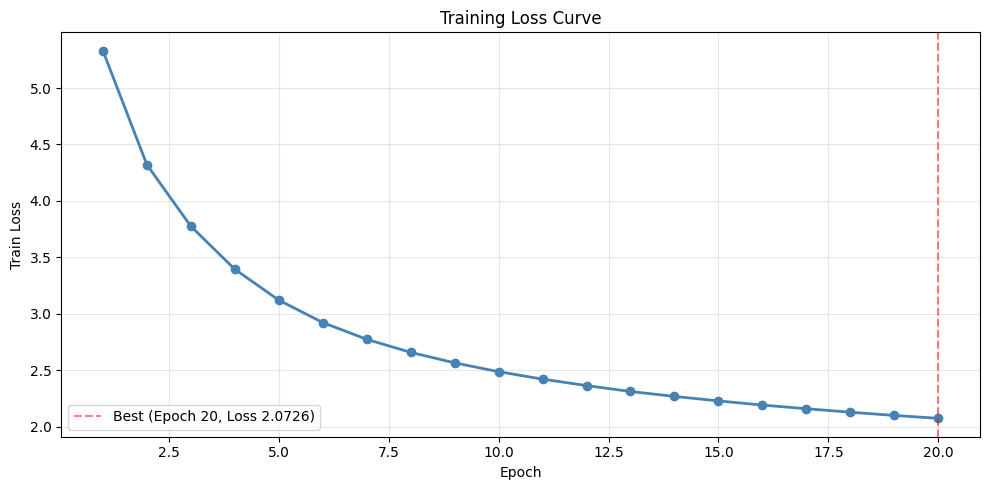

최저 Loss: 2.0726 (Epoch 20)
마지막 Loss: 2.0726


In [ ]:
# Loss 곡선 시각화
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Epoch')
plt.ylabel('Train Loss')
plt.title('Training Loss Curve')
plt.grid(True, alpha=0.3)

# Best 시점 표시
best_epoch = train_losses.index(min(train_losses)) + 1
plt.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.5,
            label=f'Best (Epoch {best_epoch}, Loss {min(train_losses):.4f})')
plt.legend()
plt.tight_layout()
plt.show()

print(f"최저 Loss: {min(train_losses):.4f} (Epoch {best_epoch})")
print(f"마지막 Loss: {train_losses[-1]:.4f}")

- Loss 추이 : 5.33 -> 2.07로 감소
- 초반급감 -> 후판 완만한 곡선형태로 학습패턴
- Epoch 20일 때가 Loss 기준 최저점

### 5-6. 최종 번역 결과 + Attention Map

학습이 끝난 후 **Best 모델**을 로드하여 4개 예문에 대해:

1. **최종 번역 결과** 출력
2. **Attention Map 시각화** — 각 영어 단어가 어떤 한국어 토큰에 주목했는지

**Attention Map 해석법:**
- 가로축: 한국어 입력 토큰
- 세로축: 영어 출력 토큰
- 밝은 색 = 높은 attention (강한 연관)
- 일반적으로 **대각선 형태**가 나오면 정렬이 잘 학습된 것

In [ ]:
# 학습 중 저장한 Best 모델 로드 (마지막 모델보다 성능이 좋을 수 있음)
model.load_state_dict(torch.load('best_model.pt'))
model.eval()
print("# Best 모델 로드 완료\n")

print("=" * 60)
print("# 최종 번역 결과")
print("=" * 60)

for i, sent in enumerate(TEST_SENTENCES, 1):
    result, _, _ = translate(sent, model, kor_tokenizer, eng_tokenizer)
    print(f"\nK{i}) {sent}")
    print(f"     → {result}")

# Best 모델 로드 완료

# 최종 번역 결과

K1) 오바마는 대통령이다.
     → obama s remarks .

K2) 시민들은 도시 속에 산다.
     → citizens cities in the florence neighborhood .

K3) 커피는 필요 없다.
     → coffee is especially coffee .

K4) 일곱 명의 사망자가 발생했다.
     → seven of the fatalities were killed in the disaster zone .


- Loss는 점차 낮아졌는데, 번역 결과는 좋지 않음.
- Loss가 최저라고 해서 최고의 번역은 아니었음.
- Epoch별 번역 결과를 확인해서 최적의 Epoch를 번역 로그를 보고 확인해 봐야겠음.

- 시각화 할 때 경고 모두 숨김

In [ ]:
# 경고 숨김
import warnings
import logging

# 1) Glyph missing 경고 직접 매칭
warnings.filterwarnings('ignore', message='Glyph.*missing from font')

# 2) findfont 경고 매칭
warnings.filterwarnings('ignore', message='findfont.*not found')

# 3) UserWarning 전체 차단 (Glyph 경고 포함)
warnings.filterwarnings('ignore', category=UserWarning)

# 4) matplotlib 관련 모든 로거 ERROR 레벨로
logging.getLogger('matplotlib').setLevel(logging.ERROR)
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

print("## 모든 경고 숨김 완료")

## 모든 경고 숨김 완료


- 그래프에 한글 깨져서 폰트 설치

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import urllib.request
import os

# NanumGothic 폰트 다운로드
font_url = "https://github.com/google/fonts/raw/main/ofl/nanumgothic/NanumGothic-Regular.ttf"
font_path = "/tmp/NanumGothic.ttf"

if not os.path.exists(font_path):
    urllib.request.urlretrieve(font_url, font_path)

# matplotlib에 폰트 등록
fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()
plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

print(f"✅ 한글 폰트 적용: {font_name}")

✅ 한글 폰트 적용: NanumGothic


# Attention Map (예문별)

--- K1) 오바마는 대통령이다. ---


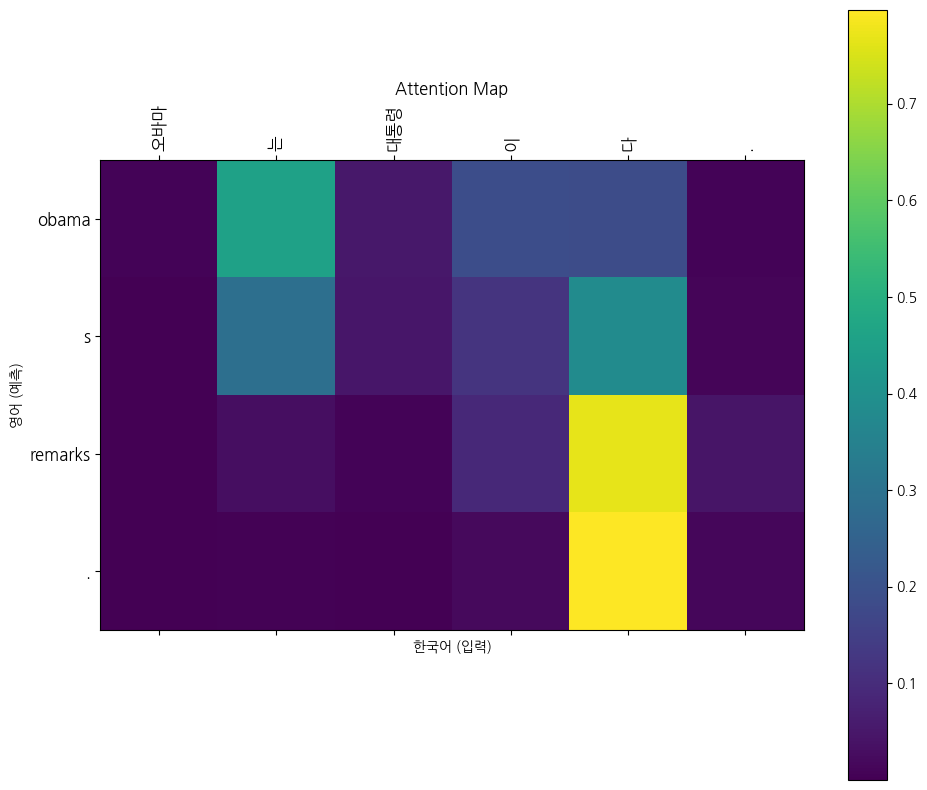

번역: obama s remarks .

--- K2) 시민들은 도시 속에 산다. ---


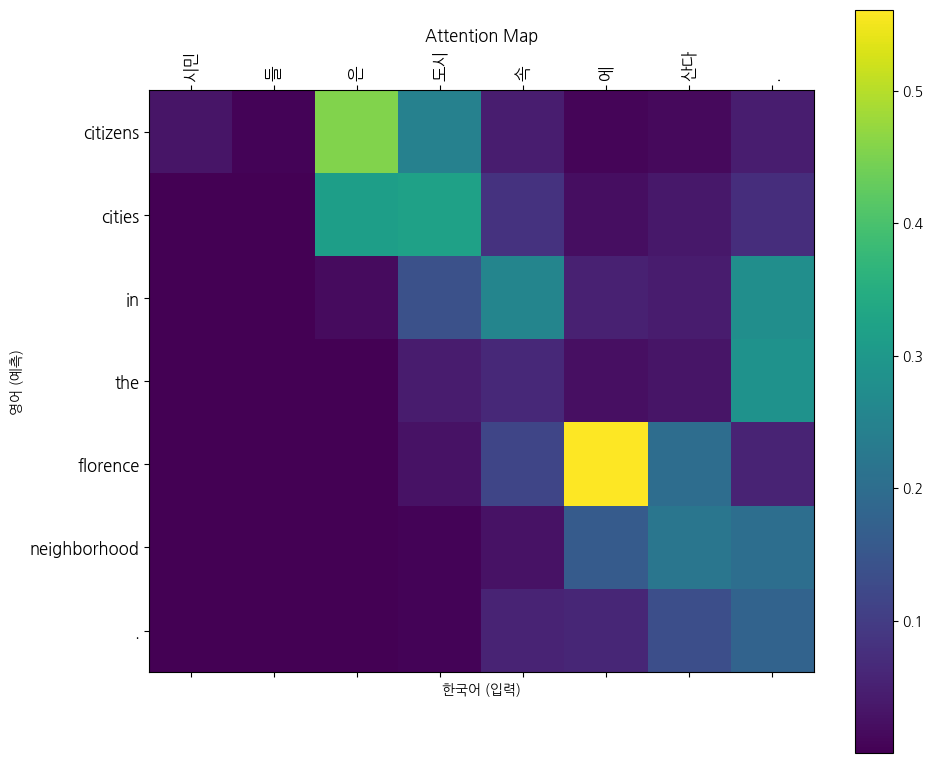

번역: citizens cities in the florence neighborhood .

--- K3) 커피는 필요 없다. ---


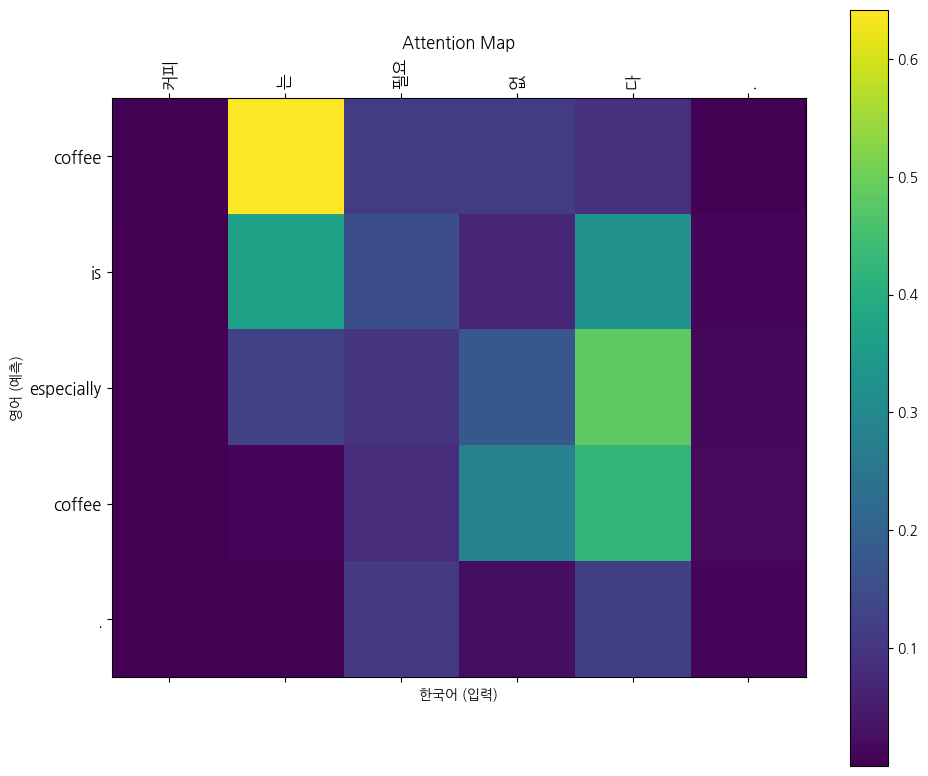

번역: coffee is especially coffee .

--- K4) 일곱 명의 사망자가 발생했다. ---


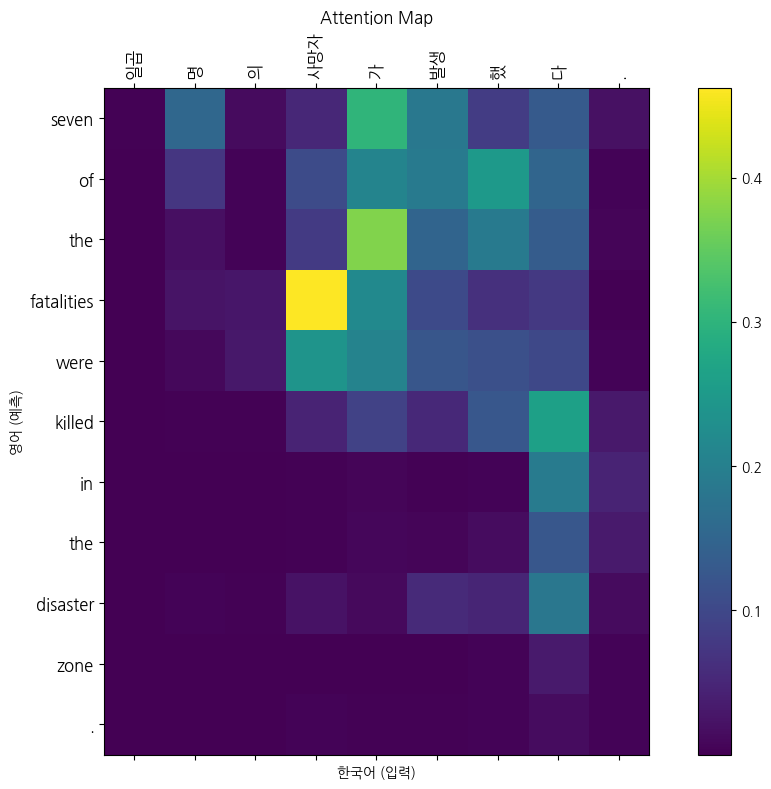

번역: seven of the fatalities were killed in the disaster zone .


In [ ]:
# Attention Map 시각화
print("=" * 60)
print("# Attention Map (예문별)")
print("=" * 60)

for i, sent in enumerate(TEST_SENTENCES, 1):
    print(f"\n--- K{i}) {sent} ---")
    result, _, _ = translate(sent, model, kor_tokenizer, eng_tokenizer, plot=True)
    print(f"번역: {result}")

- 마지막 Epoch 결과로 그래프 생성되므로 정답이 틀려서 그래프가 의미가 없어보임.

In [ ]:
# 에폭별 번역 변화 추적
# 학습이 진행되면서 번역이 어떻게 변했는지 확인
print("=" * 60)
print("## 에폭별 번역 변화")
print("=" * 60)

for sent, results in translation_history.items():
    print(f"\n[입력] {sent}")
    print("-" * 50)
    for ep, res in enumerate(results, 1):
        marker = "* " if ep == best_epoch else "  "
        print(f"  {marker} Epoch {ep:2}: {res}")

## 에폭별 번역 변화

[입력] 오바마는 대통령이다.
--------------------------------------------------
     Epoch  1: obama s president barack obama is a great president .
     Epoch  2: obama is the president .
     Epoch  3: obama is the president .
     Epoch  4: obama is the president s first lady .
     Epoch  5: obama is the president .
     Epoch  6: obama is the president .
     Epoch  7: obama is the president .
     Epoch  8: obama is the president .
     Epoch  9: obama s lead is a reminder .
     Epoch 10: obama is the president .
     Epoch 11: obama is the president .
     Epoch 12: obama is the president .
     Epoch 13: obama is the president .
     Epoch 14: obama is the president .
     Epoch 15: obama is the president .
     Epoch 16: obama is the president .
     Epoch 17: obama is the president .
     Epoch 18: obama is the president .
     Epoch 19: obama is the president .
  *  Epoch 20: obama s remarks .

[입력] 시민들은 도시 속에 산다.
--------------------------------------------------
     Ep

**결과**
- 번역 히스토리를 보니 Epoch 15가 가장 적절해 보임.
- Loss는 끝까지 줄어들었지만, Epoch 15 부근에서 정점에 도달한 후 점차 학습 데이터 표현에 과적합되는 경향을 보임.
- 검증 데이터셋이 없는 환경에서 Loss만으로는 모델 선택이 어렵다는 것을 보여줌.

**Best 번역**
- K1) 오바마는 대통령이다. -> Epoch 2-17 : obama is the president .
- K2) 시민들은 도시 속에 산다. -> Epoch 9 : citizens are in cities .
- K3) 커피는 필요 없다. -> Epoch 15 : coffee is no need for coffee .
- K4) 일곱 명의 사망자가 발생했다. -> Epoch 10-16 : seven people were killed .

### 5-7. 추가실험
- Epoch 20 결과 Epoch 15가 학습에 가장 적절하다 판단되어 재학습 진행해보기로함.
- 배치크기 : 64 -> 128 늘림. (시간 줄이기 위해)
- EPOCH : 20 -> 15 줄임. (이전 학습에서 Epoch15 이후 과적합였음)
- 매 Epoch마다 체크포인트 저장

In [ ]:
import time
import os
import torch
import torch.optim as optim
from torch.utils.data import DataLoader

# === 1) 배치 크기 ↑ (이게 핵심 변경점) ===
BATCH_SIZE = 128   # 64 → 128 (시간 절반)

train_dataset = TranslationDataset(kor_tensor, eng_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
print(f"배치 수: {len(train_loader)} (배치 크기 {BATCH_SIZE})\n")

# === 2) 모델 완전 초기화 (새 학습) ===
attention = BahdanauAttention(HID_DIM)
encoder = Encoder(INPUT_DIM, EMB_DIM, HID_DIM, DROPOUT)
decoder = Decoder(OUTPUT_DIM, EMB_DIM, HID_DIM, attention, DROPOUT)
model = Seq2SeqAttention(encoder, decoder, device).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# === 3) 체크포인트 디렉토리 ===
CKPT_DIR = "./checkpoints"
os.makedirs(CKPT_DIR, exist_ok=True)

# === 4) 학습 설정 ===
TEST_SENTENCES = [
    "오바마는 대통령이다.",
    "시민들은 도시 속에 산다.",
    "커피는 필요 없다.",
    "일곱 명의 사망자가 발생했다."
]

EPOCHS = 15   # 20 -> 15 변경
train_losses = []
translation_history = {sent: [] for sent in TEST_SENTENCES}
best_loss = float('inf')

print("=" * 60)
print(f"# 학습 시작 (배치 {BATCH_SIZE}, {EPOCHS} 에폭, 체크포인트 저장)")
print("=" * 60)
start_time = time.time()

# === 5) 학습 루프 ===
for epoch in range(EPOCHS):
    train_loss = train_step(model, train_loader, optimizer, criterion, epoch)
    train_losses.append(train_loss)

    print(f"\n## Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f}")

    # 예문 번역
    print("## 예문 번역:")
    for sent in TEST_SENTENCES:
        result, _, _ = translate(sent, model, kor_tokenizer, eng_tokenizer)
        translation_history[sent].append(result)
        print(f"  KO: {sent}")
        print(f"  EN: {result}")

    # 매 에폭 체크포인트 저장
    ckpt_path = f"{CKPT_DIR}/epoch_{epoch+1:02d}.pt"
    torch.save(model.state_dict(), ckpt_path)
    print(f"  === 저장: {ckpt_path}")

    # Best 모델 별도 저장
    if train_loss < best_loss:
        best_loss = train_loss
        torch.save(model.state_dict(), 'best_model.pt')
        print(f"  *** Best 갱신 (loss={best_loss:.4f})\n")

elapsed = time.time() - start_time
print(f"\n{'=' * 60}")
print(f"# 완료 | 총 시간: {elapsed/60:.1f}분 | Best Loss: {best_loss:.4f}")
print(f"{'=' * 60}")

배치 수: 479 (배치 크기 128)

# 학습 시작 (배치 128, 15 에폭, 체크포인트 저장)


Epoch 1: 100%|██████████| 479/479 [03:47<00:00,  2.10it/s, loss=5.0484]



## Epoch 1/15 | Train Loss: 5.5231
## 예문 번역:
  KO: 오바마는 대통령이다.
  EN: obama is expected to be the first lady .
  KO: 시민들은 도시 속에 산다.
  EN: the <unk> are <unk> .
  KO: 커피는 필요 없다.
  EN: i don t know the <unk> .
  KO: 일곱 명의 사망자가 발생했다.
  EN: the two men were killed in the past .
  === 저장: ./checkpoints/epoch_01.pt
  *** Best 갱신 (loss=5.5231)



Epoch 2: 100%|██████████| 479/479 [03:47<00:00,  2.10it/s, loss=4.0917]



## Epoch 2/15 | Train Loss: 4.5327
## 예문 번역:
  KO: 오바마는 대통령이다.
  EN: obama is a president .
  KO: 시민들은 도시 속에 산다.
  EN: they are in the midst of the <unk> .
  KO: 커피는 필요 없다.
  EN: i don t know what i m .
  KO: 일곱 명의 사망자가 발생했다.
  EN: the death toll in the hospital .
  === 저장: ./checkpoints/epoch_02.pt
  *** Best 갱신 (loss=4.5327)



...


## Epoch 13/15 | Train Loss: 2.3543
## 예문 번역:
  KO: 오바마는 대통령이다.
  EN: obama is a president .
  KO: 시민들은 도시 속에 산다.
  EN: citizens from the cities , which is buried in suburban cities .
  KO: 커피는 필요 없다.
  EN: coffee has no more vitamin .
  KO: 일곱 명의 사망자가 발생했다.
  EN: seven people were killed in the insurgency .
  === 저장: ./checkpoints/epoch_13.pt
  *** Best 갱신 (loss=2.3543)



Epoch 14: 100%|██████████| 479/479 [03:49<00:00,  2.09it/s, loss=2.3219]



## Epoch 14/15 | Train Loss: 2.2983
## 예문 번역:
  KO: 오바마는 대통령이다.
  EN: obama s projected is not going to be president
  KO: 시민들은 도시 속에 산다.
  EN: citizens in cities across the city of <unk> .
  KO: 커피는 필요 없다.
  EN: coffee has never heard of anything
  KO: 일곱 명의 사망자가 발생했다.
  EN: seven deaths were killed .
  === 저장: ./checkpoints/epoch_14.pt
  *** Best 갱신 (loss=2.2983)



Epoch 15: 100%|██████████| 479/479 [03:48<00:00,  2.10it/s, loss=2.3977]



## Epoch 15/15 | Train Loss: 2.2481
## 예문 번역:
  KO: 오바마는 대통령이다.
  EN: obama s president , he is in the first african nation .
  KO: 시민들은 도시 속에 산다.
  EN: they were in cities across the city .
  KO: 커피는 필요 없다.
  EN: coffee is a little bit of coffee .
  KO: 일곱 명의 사망자가 발생했다.
  EN: seven people were killed .
  === 저장: ./checkpoints/epoch_15.pt
  *** Best 갱신 (loss=2.2481)


# 완료 | 총 시간: 57.2분 | Best Loss: 2.2481


**결과**
- 배치 사이즈 (64->128)를 늘린다고 해서 속도 향상이 반으로 줄어들지는 않았음.
- Epoch 횟수를 줄여서 업데이트 횟수 감소로 Loss가 이전 결과보다 올라감 -> 2.2481 (이전 2.0726보다 ↑)

**Best 번역**
- K1) 오바마는 대통령이다.         -> Epoch 13 : obama is a president .
- K2) 시민들은 도시 속에 산다.     -> Epoch 15 : they were in cities across the city .
- K3) 커피는 필요 없다.            -> Epoch 7 : coffee is not necessary
- K4) 일곱 명의 사망자가 발생했다. -> Epoch 15 : seven people were killed .

**결론**
- K1, K3는 Epoch15에서 엉뚱한 번역을 했는데, 이전 배치사이즈 64였을 때는 번역이 잘 되었었기에, 배치사이즈 64가 동일 Epoch로 비교시 더 나은 번역 결과나 나타남을 알 수 있다.

## Step 6. 최종결과

### 6-1. 예문/제출


| 예문 | 제출 CASE 1 (Batch 64 / Epoch 20) | 제출 CASE 2 (Batch 128 / Epoch 15) |
| :--- | :--- | :--- |
| **K1) 오바마는 대통령이다.** | E1)Epoch 2-17 : obama is the president . | E1)Epoch 13 : obama is a president . |
| **K2) 시민들은 도시 속에 산다.** | E2)Epoch 9 : citizens are in cities . | E2)Epoch 15 : they were in cities across the city . |
| **K3) 커피는 필요 없다.** | E3)Epoch 15 : coffee is no need for coffee . | E3)Epoch 7 : coffee is not necessary |
| **K4) 일곱 명의 사망자가 발생했다.** | E4)Epoch 10-16 : seven people were killed . | E4)Epoch 15 : seven people were killed . |

- 배치 사이즈를 64에서 128로 늘린 실험에서는 일부 문장에서 더 좋은 번역이 나오기도 했지만, 전체적으로는 배치 사이즈 64 실험이 더 안정적인 결과를 보였다. 따라서 이번 데이터와 모델 구조에서는 배치 사이즈 64 / Epoch 20 실험이 더 적절한 설정으로 판단된다.

### 6-2. 최종정리

1. Train Loss만으로 번역 품질을 판단하기 어렵다.
2. Best Loss 모델이 Best Translation 모델은 아닐 수 있다.
3. Epoch별 번역 결과를 직접 확인하는 과정이 중요하다.
4. 검증 데이터셋 없이 Train Loss만 보는 것은 한계가 있다.
5. 배치 사이즈 변경은 학습 속도뿐 아니라 번역 품질에도 영향을 준다.
6. 제한된 데이터셋 학습으로 충분한 한국어표현 학습이 어려웠다.
7. 매순간 가장 확률이 높은 단어를 고르는 Greedy Decoding방식은 단어를 잘못 고르면 뒤 문장이 계속 어색해 질 수 있다.

## Step 7. 회고

이번 실험에서 Seq2Seq + Bahdanau Attention 기반 한영 번역 모델을 구현하고, 동일한 테스트 문장에 대해 두 가지 설정으로 학습 결과를 비교하였다.

첫 번째 실험은 배치 사이즈 64, Epoch 20으로 진행하였고, 두 번째 실험은 학습 시간을 줄이고 과적합을 피하기 위해 배치 사이즈 128, Epoch 15로 변경하여 진행하였다.

실험 결과, 학습 Loss는 Epoch이 증가할수록 전반적으로 감소하였다. 하지만 Loss가 가장 낮은 시점의 모델이 항상 가장 좋은 번역 결과를 내지는 않았다. 특히 일부 문장에서는 중간 Epoch에서 더 자연스러운 번역이 나왔고, 이후 Epoch이 증가하면서 오히려 어색하거나 반복적인 번역이 나타났다.

예를 들어, "커피는 필요 없다."의 경우 배치 사이즈 64에서는 Epoch 15에서 "coffee is no need for coffee ."라는 다소 어색한 결과가 나왔지만, 배치 사이즈 128에서는 Epoch 7에서 "coffee is not necessary"라는 더 자연스러운 번역이 나왔다. 반면 "시민들은 도시 속에 산다."는 배치 사이즈 64의 Epoch 9 결과인 "citizens are in cities ."가 배치 사이즈 128의 결과보다 더 간결하고 적절했다.

또한 "일곱 명의 사망자가 발생했다."는 두 실험 모두에서 "seven people were killed ."라는 비교적 좋은 번역을 생성하였다.

처음에는 Loss가 낮아지면 번역 품질도 자연스럽게 좋아질 것이라고 생각했지만, 실제 결과는 그렇지 않았다. Loss는 계속 감소했지만, 번역 결과는 특정 Epoch 이후 오히려 어색해지는 경우가 있었다. 이를 통해 모델 학습에서 숫자 지표와 실제 결과를 함께 보는 것이 중요하다는 것을 알게 되었다.

또한 검증 데이터셋 없이 학습 데이터 Loss만으로 모델을 선택하는 것은 한계가 있었다. Train Loss는 학습 데이터에 대한 오차만 보여주기 때문에, 실제 새로운 문장에 대해 좋은 번역을 하는지 판단하기 어렵다. 이번 실험에서는 테스트 문장 4개를 매 Epoch마다 직접 확인하면서 Best Epoch을 찾았지만, 더 정확한 평가를 위해서는 별도의 Validation Set이 필요하다고 느꼈다.

배치 사이즈 실험도 의미가 있었다. 배치 사이즈를 64에서 128로 늘리면 학습 시간이 크게 줄어들 것으로 예상했지만, 실제로는 기대만큼 줄어들지 않았다. 또한 배치 사이즈가 커지면서 업데이트 횟수가 줄어들고, 일부 문장에서는 번역 품질이 떨어지는 현상도 확인하였다. 이를 통해 배치 사이즈는 단순히 크게 하는 것이 좋은 것이 아니라, 데이터 크기와 모델 구조에 맞게 조정해야 한다는 점을 알게 되었다.

GPU 사용에 대한 한계가 있긴 하나, 더 실험해 보고 싶은 것이 있다면, 동일조건으로 형태소 분석 Mecab 대신 SentencePiece 적용해보거나,  현재 모델 조건 그대로 두고 매 순간 가장 확률이 높은 단어 하나만 선택하는 Greedy Decoding 대신 후보 여러개를 유지하면서 최종 번역을 고르는 Beam Search로 추론 방식을 바꿔서 결과를 비교해 보고 싶다.
